# Chapter 25 — Irrational Numbers

> **Prerequisites:** ch024 (Rational Numbers), ch023 (Integers)
> 
> **You will learn:**
> - The proof that √2 is irrational — one of mathematics' most important proofs
> - Why irrationals cannot be stored exactly in any finite representation
> - Continued fractions as the best rational approximation of irrationals
> - The ubiquity of irrationals in geometry and algorithms
> 
> **Environment:** Python 3.x, numpy, matplotlib, fractions

---

## 1. Concept

An irrational number is a real number that cannot be written as $p/q$ for any integers $p, q$. The first proven irrational was $\sqrt{2}$, discovered by the Pythagoreans around 500 BCE — a result so disturbing to their worldview that, according to legend, the discoverer was drowned.

Irrationals include:
- $\sqrt{2}, \sqrt{3}, \sqrt{5}$ (square roots of non-perfect-squares)
- $\pi = 3.14159\ldots$ (ratio of circle circumference to diameter)
- $e = 2.71828\ldots$ (base of natural logarithm)
- $\phi = (1+\sqrt{5})/2$ (golden ratio)

**Common misconception:** "Irrationals are just numbers we haven't found the fraction for yet." Wrong. The proof that $\sqrt{2}$ is irrational shows it is *impossible* to express it as a fraction — not merely unknown.

**Practical consequence:** No computer can store an irrational exactly. Every floating-point number is rational. When you write `math.pi`, you get a rational approximation with 15–17 significant digits.

## 2. Intuition & Mental Models

**The diagonal of a unit square:** A square with side 1 has diagonal $\sqrt{2}$. You can *construct* this length with a ruler and compass — you can draw it, measure it, hold it in your hand. But you cannot write it as a fraction. Geometry produces numbers that arithmetic cannot name.

**Non-repeating, non-terminating decimals:** Every rational has a decimal expansion that either terminates or repeats (e.g., $1/3 = 0.\overline{3}$, $1/7 = 0.\overline{142857}$). Irrationals never terminate and never repeat. This is an if-and-only-if characterization.

**Continued fractions as best rational approximations:** The fraction $22/7$ is a famous approximation of $\pi$. But $355/113$ is far better. Continued fractions give the *optimal* sequence of rational approximations to any irrational — no fraction with a smaller denominator is closer.

*(Recall from ch024: ℚ is dense in ℝ — but despite this density, most real numbers are irrational.)*

## 3. Visualization

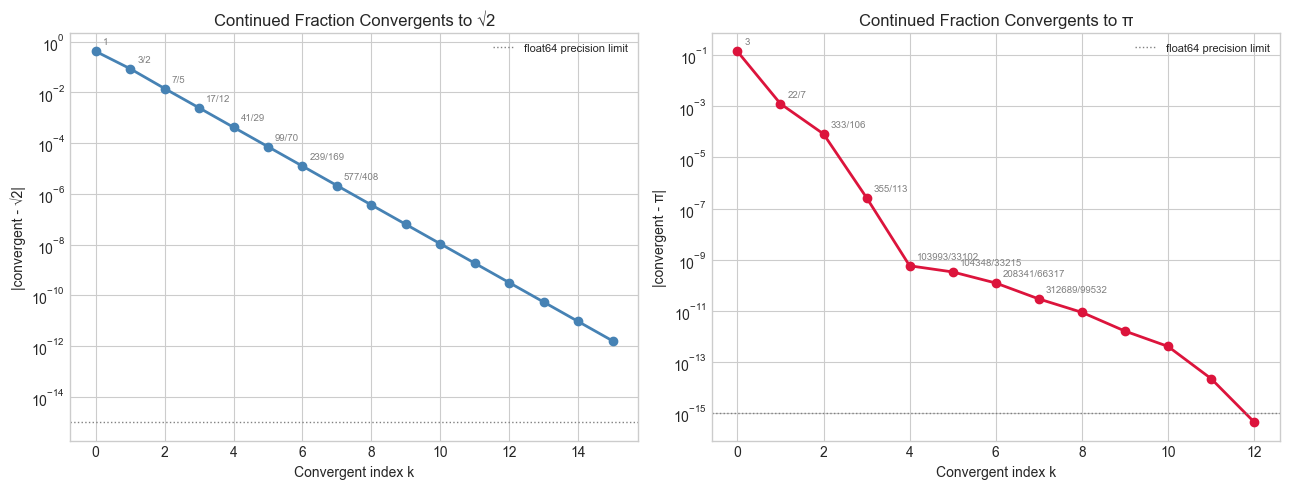

Best approximations to π:
  3 = 3.0000000000  (error: 1.42e-01)
  22/7 = 3.1428571429  (error: 1.26e-03)
  333/106 = 3.1415094340  (error: 8.32e-05)
  355/113 = 3.1415929204  (error: 2.67e-07)
  103993/33102 = 3.1415926530  (error: 5.78e-10)
  104348/33215 = 3.1415926539  (error: 3.32e-10)


In [1]:
# --- Visualization: Rational approximations converging to √2 and π ---
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
plt.style.use('seaborn-v0_8-whitegrid')

def continued_fraction_convergents(coeffs):
    """
    Compute convergents of a continued fraction [a0; a1, a2, ...].

    Args:
        coeffs: list of int continued fraction coefficients

    Returns:
        list of Fraction: convergents p_k/q_k
    """
    convergents = []
    p_prev, p_curr = 1, coeffs[0]
    q_prev, q_curr = 0, 1
    convergents.append(Fraction(p_curr, q_curr))

    for a in coeffs[1:]:
        p_prev, p_curr = p_curr, a * p_curr + p_prev
        q_prev, q_curr = q_curr, a * q_curr + q_prev
        convergents.append(Fraction(p_curr, q_curr))

    return convergents

# √2 = [1; 2, 2, 2, 2, ...]
sqrt2_coeffs = [1] + [2] * 15
sqrt2_convergents = continued_fraction_convergents(sqrt2_coeffs)

# π ≈ [3; 7, 15, 1, 292, 1, 1, 1, 2, ...]
pi_coeffs = [3, 7, 15, 1, 292, 1, 1, 1, 2, 1, 3, 1, 14]
pi_convergents = continued_fraction_convergents(pi_coeffs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, convergents, true_val, name, color in [
    (axes[0], sqrt2_convergents, np.sqrt(2), '√2', 'steelblue'),
    (axes[1], pi_convergents,   np.pi,      'π',  'crimson')
]:
    errors = [abs(float(c) - true_val) for c in convergents]
    denoms = [c.denominator for c in convergents]

    ax.semilogy(range(len(errors)), errors, 'o-', color=color, linewidth=2)
    for i, (c, e) in enumerate(zip(convergents, errors)):
        if i < 8:
            ax.annotate(f'{c}', (i, e), textcoords='offset points',
                        xytext=(5, 5), fontsize=7, color='gray')

    ax.axhline(1e-15, color='gray', linestyle=':', linewidth=1,
               label='float64 precision limit')
    ax.set_xlabel('Convergent index k')
    ax.set_ylabel(f'|convergent - {name}|')
    ax.set_title(f'Continued Fraction Convergents to {name}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Best approximations to π:")
for c in pi_convergents[:6]:
    print(f"  {c} = {float(c):.10f}  (error: {abs(float(c)-np.pi):.2e})")

## 4. Mathematical Formulation

**Proof that √2 is irrational** (proof by contradiction):

Assume $\sqrt{2} = p/q$ in lowest terms (so $\gcd(p,q) = 1$).

Then $2 = p^2/q^2$, so $p^2 = 2q^2$.

This means $p^2$ is even, so $p$ is even. Write $p = 2k$.

Then $4k^2 = 2q^2$, so $q^2 = 2k^2$, so $q$ is even.

But then both $p$ and $q$ are even — contradicting $\gcd(p,q) = 1$. $\square$

**Continued fraction representation:**
Any real $x$ has a continued fraction expansion:
$$x = a_0 + \cfrac{1}{a_1 + \cfrac{1}{a_2 + \cfrac{1}{a_3 + \cdots}}}$$
denoted $[a_0; a_1, a_2, a_3, \ldots]$. $x$ is rational iff this expansion is finite. $\sqrt{2} = [1; 2, 2, 2, \ldots]$ — the simplest infinite continued fraction.

**Best approximation theorem:** The convergents $p_k/q_k$ of the continued fraction of $x$ satisfy: no fraction $p/q$ with $q \leq q_k$ is closer to $x$ than $p_k/q_k$.

## 5. Python Implementation

In [2]:
# --- Implementation: Continued fraction expansion and irrationality test ---
import math
from fractions import Fraction

def to_continued_fraction(x, max_terms=20, tol=1e-10):
    """
    Compute the continued fraction expansion of float x.

    Args:
        x: float
        max_terms: int, maximum number of coefficients
        tol: float, stop when fractional part is smaller than this

    Returns:
        list of int: continued fraction coefficients [a0, a1, a2, ...]
    """
    coeffs = []
    for _ in range(max_terms):
        a = int(x)         # floor
        coeffs.append(a)
        frac = x - a       # fractional part
        if frac < tol:
            break
        x = 1.0 / frac     # reciprocal of fractional part
    return coeffs


def is_likely_rational(x, max_denom=10000):
    """
    Heuristic: check if x is 'close enough' to a rational with small denominator.

    Args:
        x: float
        max_denom: int

    Returns:
        Fraction or None
    """
    f = Fraction(x).limit_denominator(max_denom)
    if abs(float(f) - x) < 1e-10:
        return f
    return None


print("Continued fraction expansions:")
test_vals = [
    (math.sqrt(2), '√2'),
    (math.pi, 'π'),
    (math.e, 'e'),
    ((1 + math.sqrt(5)) / 2, 'φ (golden ratio)'),
    (22/7, '22/7'),
    (355/113, '355/113'),
]
for val, name in test_vals:
    cf = to_continued_fraction(val, max_terms=10)
    rat = is_likely_rational(val)
    print(f"  {name:20s}: [{'; '.join(map(str, cf[:6]))}...]  rational? {rat}")

Continued fraction expansions:
  √2                  : [1; 2; 2; 2; 2; 2...]  rational? None
  π                   : [3; 7; 15; 1; 292; 1...]  rational? None
  e                   : [2; 1; 2; 1; 1; 4...]  rational? None
  φ (golden ratio)    : [1; 1; 1; 1; 1; 1...]  rational? None
  22/7                : [3; 7...]  rational? 22/7
  355/113             : [3; 7; 16...]  rational? 355/113


## 6. Experiments

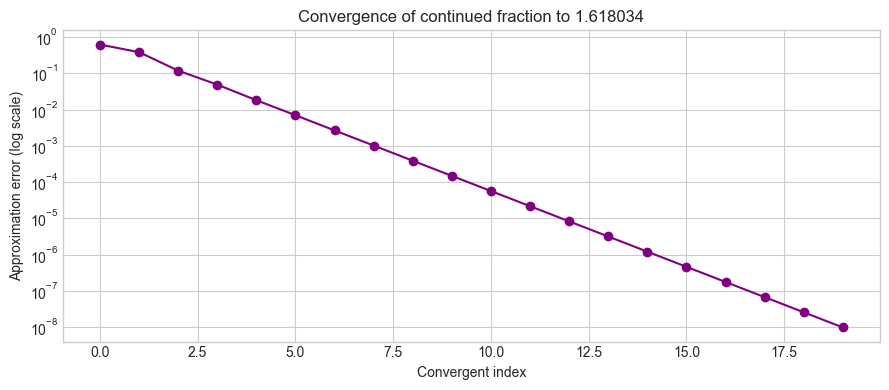

CF coefficients: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
(All 1s = golden ratio — slowest possible convergence)


In [3]:
# --- Experiment 1: The golden ratio has the 'worst' rational approximations ---
# Hypothesis: φ = [1;1,1,1,...] — all 1s — converges slowest to irrational
# Try changing: TARGET to other irrationals and compare convergence rate

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

phi = (1 + np.sqrt(5)) / 2  # golden ratio
TARGET = phi  # <-- try np.sqrt(2), np.pi, np.e

cf_coeffs = to_continued_fraction(TARGET, max_terms=20)
convs = continued_fraction_convergents(cf_coeffs)
errors = [abs(float(c) - TARGET) for c in convs]

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(errors, 'o-', color='purple')
ax.set_xlabel('Convergent index')
ax.set_ylabel('Approximation error (log scale)')
ax.set_title(f'Convergence of continued fraction to {TARGET:.6f}')
plt.tight_layout()
plt.show()

print(f"CF coefficients: {cf_coeffs}")
print("(All 1s = golden ratio — slowest possible convergence)")

In [4]:
# --- Experiment 2: Verify √n is irrational iff n is not a perfect square ---
# Hypothesis: for non-perfect-square n, continued fraction of √n is periodic
# Try changing: N_MAX

N_MAX = 20  # <-- modify this

import math
print(f"{'n':>4}  {'Is perfect square?':>20}  {'CF coefficients':>40}")
print('-' * 70)
for n in range(2, N_MAX + 1):
    root = math.sqrt(n)
    is_perf = int(root) ** 2 == n
    cf = to_continued_fraction(root, max_terms=12)
    print(f"{n:>4}  {'Yes' if is_perf else 'No':>20}  {str(cf[:10]):>40}")

   n    Is perfect square?                           CF coefficients
----------------------------------------------------------------------
   2                    No            [1, 2, 2, 2, 2, 2, 2, 2, 2, 2]
   3                    No            [1, 1, 2, 1, 2, 1, 2, 1, 2, 1]
   4                   Yes                                       [2]
   5                    No            [2, 4, 4, 4, 4, 4, 4, 4, 4, 4]
   6                    No            [2, 2, 4, 2, 4, 2, 4, 2, 4, 2]
   7                    No            [2, 1, 1, 1, 4, 1, 1, 1, 4, 1]
   8                    No            [2, 1, 4, 1, 4, 1, 4, 1, 4, 1]
   9                   Yes                                       [3]
  10                    No            [3, 6, 6, 6, 6, 6, 6, 6, 6, 6]
  11                    No            [3, 3, 6, 3, 6, 3, 6, 3, 6, 3]
  12                    No            [3, 2, 6, 2, 6, 2, 6, 2, 6, 2]
  13                    No            [3, 1, 1, 1, 1, 6, 1, 1, 1, 1]
  14                    No      

## 7. Exercises

**Easy 1.** Use the same proof structure as the √2 proof to show that √3 is irrational. Write the steps as Python comments alongside numeric verification.

**Easy 2.** Compute the first 10 convergents of the golden ratio $\phi = [1;1,1,1,\ldots]$ and verify they are consecutive Fibonacci ratios $F_{n+1}/F_n$.

**Medium 1.** Implement a function `decimal_expansion(numerator, denominator, n_digits)` that computes the decimal expansion of `p/q` and detects the repeating cycle. Verify: 1/7 has period 6, 1/13 has period 6.

**Medium 2.** Find the best rational approximation to $e$ with denominator ≤ 1000 using continued fractions. How many correct decimal digits does it have?

**Hard.** Liouville's theorem states that algebraic irrationals (like √2) cannot be approximated too well by rationals: $|x - p/q| > C/q^n$ for some constant $C$ depending on $x$. Design a computational experiment that demonstrates this bound is sharp for √2 by checking all convergents up to denominator $10^6$.

## 8. Mini Project

C:\Users\user\AppData\Local\Temp\ipykernel_7860\294740412.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


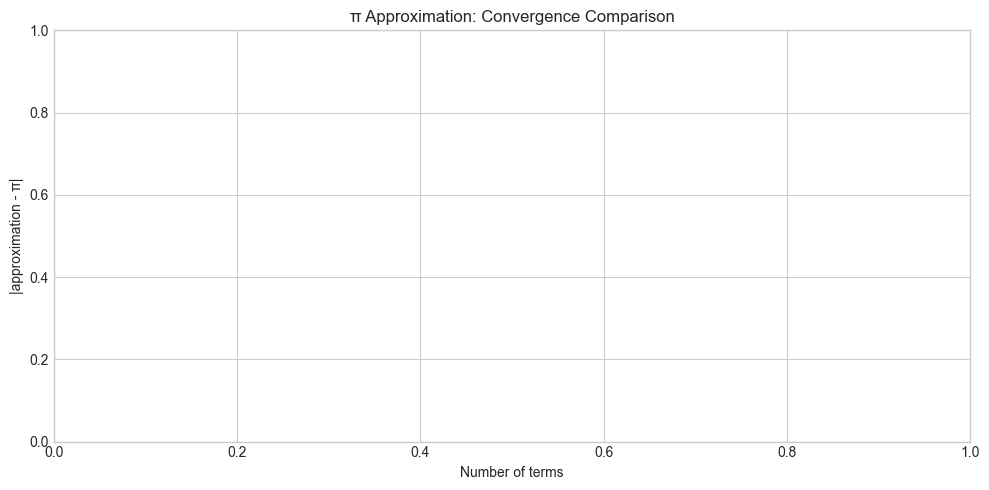

In [5]:
# --- Mini Project: π Approximation Benchmark ---
# Problem: Multiple historical formulas for π converge at different rates.
#          Which is best per computation unit?
# Task: Implement and benchmark 3 algorithms, plot their convergence.

import math
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def leibniz_pi(n_terms):
    """Leibniz formula: π/4 = 1 - 1/3 + 1/5 - 1/7 + ..."""
    # TODO: implement. Returns approximation of π after n_terms.
    pass

def nilakantha_pi(n_terms):
    """Nilakantha series: π = 3 + 4/(2·3·4) - 4/(4·5·6) + ..."""
    # TODO: implement.
    pass

def wallis_pi(n_terms):
    """Wallis product: π/2 = (2/1)(2/3)(4/3)(4/5)(6/5)(6/7)..."""
    # TODO: implement.
    pass

N_TERMS = 1000
ns = range(1, N_TERMS + 1)

methods = [
    ('Leibniz', leibniz_pi, 'steelblue'),
    ('Nilakantha', nilakantha_pi, 'crimson'),
    ('Wallis', wallis_pi, 'green'),
]

fig, ax = plt.subplots(figsize=(10, 5))
for name, fn, color in methods:
    if fn(1) is not None:  # only plot implemented methods
        errors = [abs(fn(n) - math.pi) for n in ns]
        ax.semilogy(list(ns), errors, label=name, color=color, linewidth=1.5)

ax.set_xlabel('Number of terms')
ax.set_ylabel('|approximation - π|')
ax.set_title('π Approximation: Convergence Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- Irrational numbers cannot be expressed as $p/q$ — this is provably impossible, not merely unknown.
- The proof that √2 is irrational is one of mathematics' oldest and most elegant proofs by contradiction.
- Every floating-point number is rational — irrationals are always approximated.
- Continued fractions give the optimal sequence of rational approximations to an irrational.

**Forward connections:**
- The inability to represent irrationals exactly is the root cause of floating-point error, explored in ch037 — Precision and Floating Point Errors.
- The golden ratio φ reappears in ch029 — Number Patterns and in algorithm analysis (Fibonacci heap amortized costs).
- Continued fractions reappear in ch046 — Computational Logarithms as a tool for log approximation.

**Backward connection:**
- This chapter closes the gap opened in ch024: ℚ is dense but has holes, and those holes are filled by irrationals like √2, π, and e.

**Going deeper:** The Lindemann-Weierstrass theorem proves π and e are *transcendental* — not just irrational, but not roots of any polynomial with rational coefficients. This is strictly stronger than irrationality and was proved in the 1880s.